<a href="https://colab.research.google.com/github/SIPPRE/TEL750---Digital-Image-Processing/blob/main/Spatial_filtering_using_opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Βασικό χωρικό φιλτράρισμα με χρήση OpenCV

Σε αυτό το notebook θα παρουσιαστούν τα βασικά φίλτρα που χρησιμοποιούνται στην Επεξεργασία Εικόνας για να πετύχουμε βελτίωση της ποιότητας της εικόνας. Συγκεκριμένα θα παρουσιαστούν δύο βασικές κατηγορίες φίλτρων:


1.   Φίλτρα εξομάλυνσης (Χαμηλοπερατά φίλτρα)
2.   Φίλτρα τονισμού αντίθεσης φωτεινοτήτων (υψηλοπερατά φίλτρα)

Στην αρχή θα παρουσιάσουμε τον τρόπο με τον οποίο μπορούμε να υλοποιήσουμε χωρικό φιλτράρισμα χρησιμοποιώντας οποιονδήποτε πυρήνα (kernel) θέλουμε μέσω της opencv και της python.
Κατόπιν, θα δείξουμε τον τρόπο με τον οποίο μπορούμε να υλοποιήσουμε τα φίλτρα box και τα Gaussian φίλτρα για την εξομάλυνση εικόνας και τέλος τα φίλτρα Sobel, Laplacian για την τόνωση των ακμών μιας εικόνας. 



In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow #this is used for imshow to work on google colab
from google.colab import drive
import sys
import os

In [ ]:
drive.mount('/content/gdrive')
lib_file_location = "/content/gdrive/My Drive/Courses/TEL 750 - Digital Image Processing/"
sys.path.append(lib_file_location)
from resize import ResizeWithAspectRatio

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Initial dimensions 400 X 400


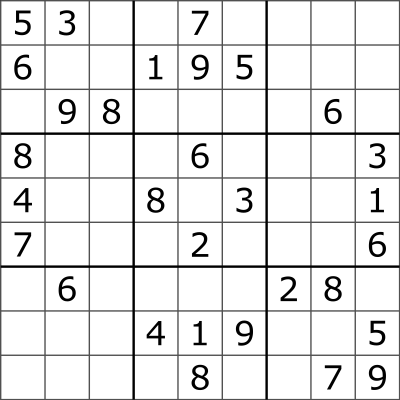

In [ ]:
# Read / Show an image
img_file = '/content/gdrive/MyDrive/Courses/TEL 750 - Digital Image Processing/sudoku.png'
image = cv2.imread(img_file) # this image is in BGR format

# Resize using my own resize function
image = ResizeWithAspectRatio(image, height=400)

# Convert image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print('Initial dimensions', gray_image.shape[0], 'X', gray_image.shape[1])
cv2_imshow(gray_image)



---



---



## Επέκταση εικόνας (χρησιμοποιείται στο χωρικό φιλτράρισμα)

### Προσθήκη περιγράμματος σταθερής φωτεινότητας

New dimensions 404 X 404


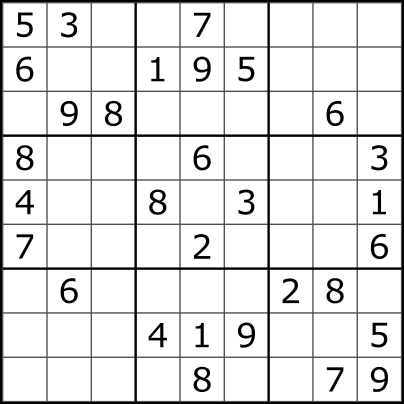

In [ ]:
gray_image1 = cv2.copyMakeBorder(gray_image, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=0)
print('New dimensions', gray_image1.shape[0], 'X', gray_image1.shape[1])
cv2_imshow(gray_image1)

### Προσθήκη περιγράμματος με αντιγραφή των άκρων της εικόνας

New dimensions 404 X 404


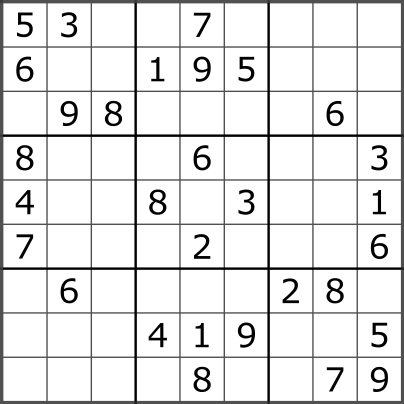

In [ ]:
gray_image2 = cv2.copyMakeBorder(gray_image, 2, 2, 2, 2, cv2.BORDER_REPLICATE)
print('New dimensions', gray_image2.shape[0], 'X', gray_image2.shape[1])
cv2_imshow(gray_image2)

### Προσθήκη περιγράμματος με κατοπτρισμό των άκρων της εικόνας

New dimensions 410 X 410


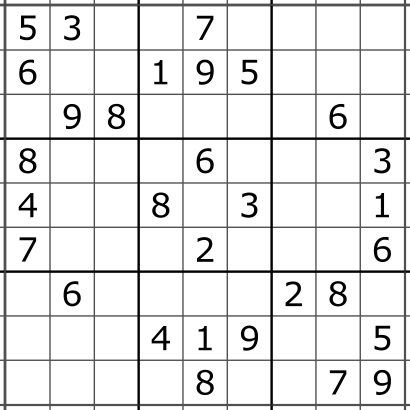

In [ ]:
gray_image3 = cv2.copyMakeBorder(gray_image, 5, 5, 5, 5, cv2.BORDER_REFLECT)
print('New dimensions', gray_image3.shape[0], 'X', gray_image3.shape[1])
cv2_imshow(gray_image3)

## Χωρικό φιλτράρισμα με χρήση πυρήνα

Σε αυτό το παράδειγμα χρησιμοποιούμε πυρήνα μεγέθους 5Χ5 με τιμές ίσες με 1/25. Στην ουσία πρόκειται για ένα φίλτρο εξομάλυνσης (box filter), αλλά στην θέση του μπορούμε να αντικαταστήσουμε με οποιονδήποτε πυρήνα θέλουμε.

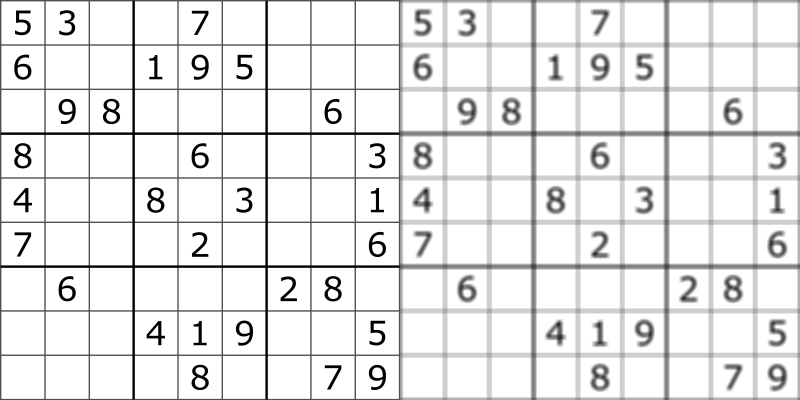

In [ ]:
kernel = np.ones((5,5),np.float32)/25 #this is a smoothing filter
filtered_img = cv2.filter2D(src=gray_image, ddepth=-1, kernel = kernel,borderType=cv2.BORDER_REFLECT)
res = np.hstack((gray_image, filtered_img))
cv2_imshow(res)

## Εξομάλυνση με χρήση box filter

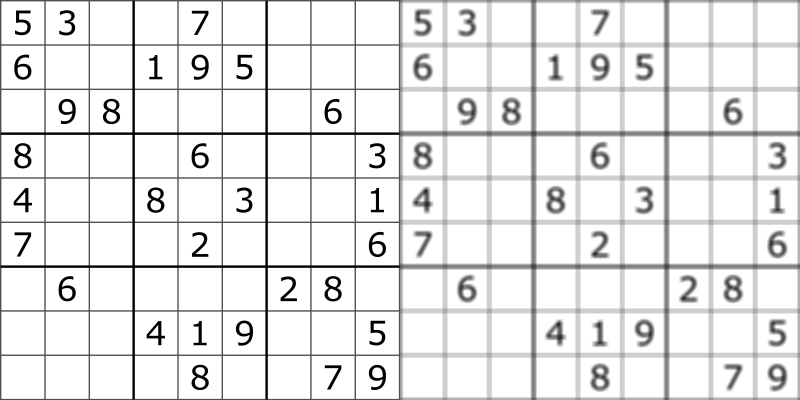

In [ ]:
blur = cv2.blur(src=gray_image, ksize=(5,5),borderType=cv2.BORDER_REFLECT)
res = np.hstack((gray_image, blur))
cv2_imshow(res)

## Εξομάλυνση με χρήση μη-κανονικοποιημένου φίλτρου box

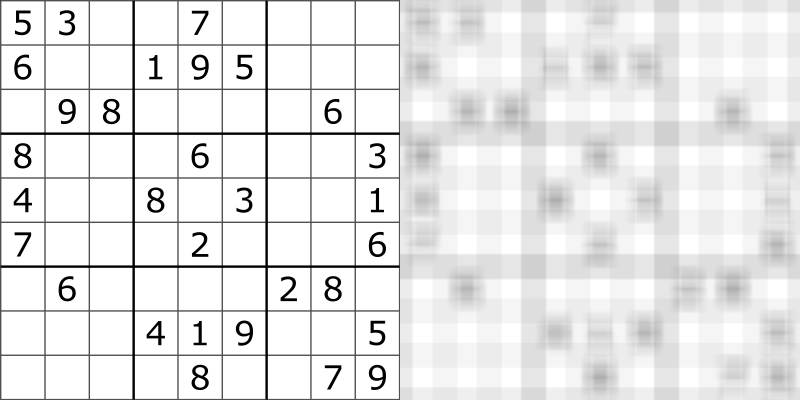

In [ ]:
box = cv2.boxFilter(src=gray_image, ddepth=-1,ksize=(25,25), normalize=True, borderType=cv2.BORDER_REFLECT)
res = np.hstack((gray_image, box))
cv2_imshow(res)

## Χωρικό φιλτράρισμα εξομάλυνσης με χρήση Gaussian φίλτρου

Στο παρακάτω κομμάτι κώδικα, παρατηρήστε ότι μπορούμε να επιλέξουμε το μέγεθος του πυρήνα καθώς και την διασπορά της gaussian συνάρτησης τόσο στον άξονα x (γραμμές) όσο και στον άξονα y (στήλες). Θυμίζουμε από την θεωρία ότι το μέγιστο μέγεθος του πυρήνα για την εξομάλυνση με Gaussian φίλτρο δεν ξεπερνάει το 6σ Χ 6σ (σ είναι η διασπορά σε κάθε κατεύθυνση). Οποιοδήποτε μέγεθος μεγαλύτερο από το παραπάνω, δεν προσθέτει κάτι στην απόδοση του φίλτρου, παρά μόνο υπολογιστική πολυπλοκότητα.

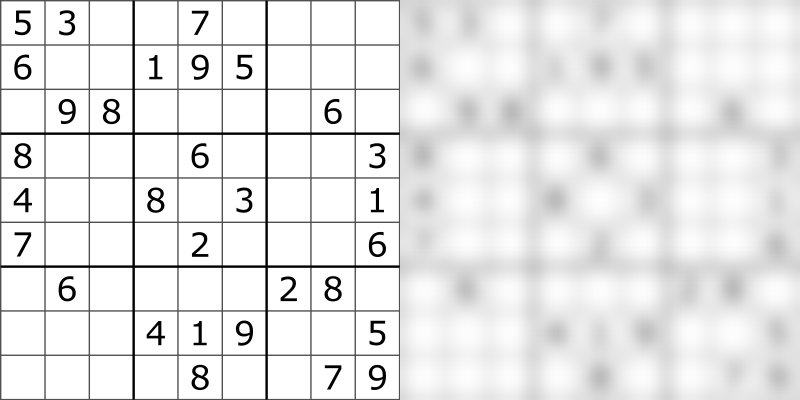

In [ ]:
gaussian_blur = cv2.GaussianBlur(src=gray_image, ksize=(51,51), sigmaX=9, sigmaY=9,borderType=cv2.BORDER_REFLECT)
res = np.hstack((gray_image, gaussian_blur))
cv2_imshow(res)

## Φίλτρα τόνωσης της όξυνσης εικόνας

Στην κατηγορία αυτή ανήκουν φίλτρα τα οποία υπολογίζουν την μεταβολή φωτεινοτήτων στους άξονες της εικόνας. Για τον λόγο αυτό χρησιμοποιούν στους υπολογισμούς τους τις παραγώγους πρώτης ή δεύτερης τάξης.

### Φίλτρα Sobel (πρώτης τάξης παράγωγοι)

Τα φίλτρα αυτά χρησιμοποιούν πυρήνα μεγέθους 3Χ3 για να υπολογίσουν ξεχωριστά τις μεταβολές φωτεινότητας κατά γραμμές και κατά στήλες της εικόνας. Ο συνδυασμός τους θα μας δώσει μια νέα εικόνα με ενισχυμένες τις ακμές και στις δύο διαστάσεις.

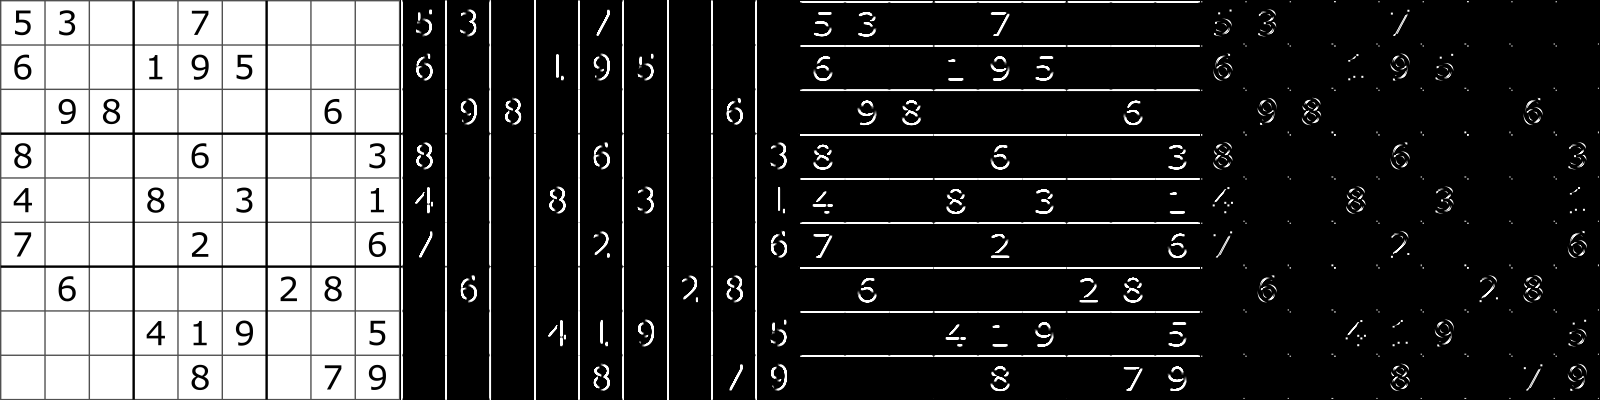

In [ ]:
sobelx = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)
sobely = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3)
sobelxy = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=3)
res = np.hstack((gray_image, sobelx, sobely, sobelxy))
cv2_imshow(res)

## Laplacian φίλτρα

Τα φίλτρα αυτά χρησιμοποιούν παραγώγους δεύτερης τάξης για τον υπολογισμό των διαφορών των φωτεινοτήτων της εικόνας

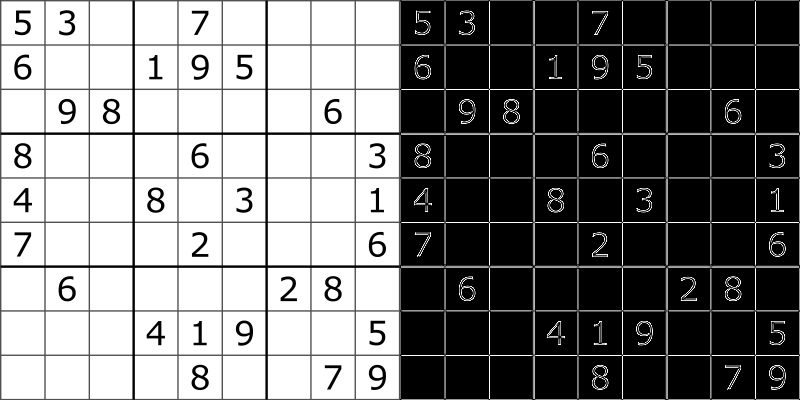

In [ ]:
# Laplacian filter
laplacian_img = cv2.Laplacian(src=gray_image, ddepth = cv2.CV_64F, borderType=cv2.BORDER_REFLECT)
res = np.hstack((gray_image, laplacian_img))
cv2_imshow(res)